# Layers of Heisenberg gates to approach a Quantum Spin Liquid on the Kagome lattice, *without* Hamiltonian calibration

**Task 1**
Spin-½ antiferromagnetic Heisenberg model on the Kagome lattice (KAFH).

---

## Summary

**Goal.** The paper uses a *hardware-efficient* ansatz
(`RealAmplitudes`: one layer of $R_y(\theta)$ + a CNOT ladder) and calibrates the
Hamiltonian (raising $J\to J'\approx 2$ on the "defect triangles") to compensate for
the ansatz's low expressiveness and approach the ground state. This task tests the
opposite hypothesis: that an ansatz built from *Heisenberg gates* (*eSWAP*),
which respect the SU(2) symmetry of the problem, can by adding layers
progressively (1) bring the state closer to a *Quantum Spin Liquid* (QSL) and
(2) reach the benchmark energy *with uniform $J=1$, no calibration*.

**Hypothesis.** The `RealAmplitudes` ansatz breaks conservation of the total spin
$S^2$; that is why it "escapes" the correct physical sector and needs the calibration
crutch. A *Hamiltonian Variational Ansatz* (HVA) made of gates
$U_H(\theta)=e^{-i\theta(XX+YY+ZZ)/4}$, starting from a dimer cover (singlets),
stays in the correct spin sector by construction, which is where the RVB/QSL-like
ground state lives.

**Results obtained** (embedded below; uniform $J=1$, zero calibration;
L-BFGS-B optimizer with analytic adjoint gradient):

| System | Ansatz | Calibration | Best energy error | $\langle S^2\rangle$ (target) |
|---|---|---|---|---|
| 19 sites (2 cells, odd → doublet) | RealAmplitudes (baseline) | none | 14.4 % | 2.18 — should be 0.75 → SU(2) broken |
| 19 sites | HVA (this work) | none | 0.52 % (symmetric→full hybrid + continuation, Sec. 4.4; full sweep alone: 0.80 %) | 0.75 exact at every depth |
| 12 sites (even cell → singlet) | HVA (this work) | none | 0.01 % (monotone drop 5.7→2.9→…→0.01) | 0.00 exact at every depth |
| 16 sites (even, scaling) | HVA (this work) | none | 0.38 % (reps=4; still decreasing) | 0.00 exact at every depth |

**Conclusions.**

1. **Symmetry is preserved for free (clean, robust result).** The HVA keeps
   $\langle S^2\rangle$ *exactly* at the correct sector value (0 for even cells,
   0.75 for the odd cluster) at every depth, while the `RealAmplitudes` baseline
   shoots up to $\langle S^2\rangle=2.18$ (SU(2) strongly broken). This is the central
   mechanism of the task: the right ansatz does not need Hamiltonian calibration
   to stay in the physical sector.

2. **Energy without calibration (the hypothesis holds).** On the even 12-site cell
   the HVA reaches 0.01 % error progressively, without touching $J$. On the odd
   19-site cluster,the one the task asks for, and the harder one the HVA reaches
   0.52 % with uniform $J=1$ via the two-phase hybrid strategy (explore with shared
   $\theta$ → refine with free $\theta$, Sec. 4.4), saturating near ~0.5 % at depth
   reps=6 (versus 14 % for the uncalibrated `RealAmplitudes` baseline): the right
   ansatz reproduces the benchmark energy without the calibration crutch.

3. **Beyond the energy (Sec. 4.6).** More demanding tests against ED: on 12 sites the
   ansatz reproduces all pair correlations at RMS 0.005 (14× better than the
   dimers), it *is* the ground state for physical purposes. On 19 sites, the 0.52 %
   state builds ~88 % of the ground state's entanglement entropy (the state's
   architecture is the right one) although the fine correlations converge more slowly
   than the energy (RMS 0.104 vs 0.152 for the dimers). The apparent "low and variable
   fidelity" problem was resolved: the 19-site ground state is a degenerate doublet
   and fidelity against a single ED vector includes a random factor; the well-defined
   metric — projection onto the doublet subspace (Sec. 4.6c) — gives F = 0.41.

4. **Scaling (Sec. 4.5).** With MPS the pipeline reaches 26–47 sites under an honest
   double-χ protocol. On 26 sites the baseline is exact but gradient-free
   optimization does not beat the dimers: the frontier at scale is access to the
   adjoint gradient (which the simulator does not expose), not memory. On 47 sites we
   establish the baseline (−69, defect gap 9.0) and the measured characterization of
   Aer-MPS's limits. Next tool: a tensor-network engine with adjoint gradient (quimb)
   or hardware.

## 1. Theoretical framework

### 1.1 The KAFH Hamiltonian and its symmetry

The antiferromagnetic Heisenberg Hamiltonian on the Kagome lattice, in the paper's
"×4" convention (Sec. 3.1, equation 1, with uniform $J=1$, *without* $H_{pert}$):

$$H \;=\; \sum_{(i,j)\in\mathcal{K}} \big(X_iX_j + Y_iY_j + Z_iZ_j\big).$$

With this normalization, a singlet $|s\rangle=(|01\rangle-|10\rangle)/\sqrt2$ on a
bond has energy $-3$ and a triplet $+1$ (instead of $-3/4$ and $+1/4$).

$H$ commutes with the total spin $S^2=\big(\sum_i \vec S_i\big)^2$ and with $S^z$
(SU(2) symmetry). Its eigenstates therefore have well-defined $S$:
- lattice with an even number of sites ⇒ singlet ground state, $S=0$;
- lattice with an odd number ⇒ doublet ground state, $S=\tfrac12$ (one free *spinon*).

This is central to the task: if the ansatz does not conserve $S^2$, it explores
states outside the physical sector and must be "pushed" back (which the paper
achieves by raising $J'$). The `RealAmplitudes` ansatz (single-qubit $R_y$ generators
and CNOTs) does not commute with $S^2$; the HVA we define below does.

### 1.2 The Heisenberg gate (eSWAP)

The two-qubit gate generated by the exchange term itself is

$$\boxed{\,U_H(\theta)=\exp\!\Big(-\,i\,\theta\,\tfrac{X_iX_j+Y_iY_j+Z_iZ_j}{4}\Big)\,}$$

Since the operator $\mathrm{SWAP}=\tfrac12(I+XX+YY+ZZ)$, one has the identity

$$U_H(\theta)=e^{\,i\theta/4}\,\mathrm{eSWAP}(\theta),\qquad
\mathrm{eSWAP}(\theta)=\cos\tfrac\theta2\,I-i\sin\tfrac\theta2\,\mathrm{SWAP},$$

hence the name *eSWAP* ("exponential SWAP"). Eigenvalues of $(XX+YY+ZZ)$: $+1$ on the
triplet (3 states) and $-3$ on the singlet, so $U_H$ applies a relative phase between
the two subspaces: it rotates population among dimers without leaving the spin
sector.

**Key property.** $[XX+YY+ZZ,\;S^2]=0$ and $[XX+YY+ZZ,\;S^z]=0$. A circuit made
only of $U_H$ gates, starting from a state with definite $S,S^z$ (e.g. a product
of singlets), remains in that spin sector. This is the *Hamiltonian Variational
Ansatz* (HVA) / RVB-inspired ansatz.

### 1.3 The HVA/RVB ansatz

1. **Initial state** = dimer cover (VBC): a product of singlets on a set of bonds
   (the same ones the paper uses as a starting point). A product of singlets is
   already a global singlet; unpaired qubits (*spinons*, odd cases) stay in
   $|0\rangle$ and contribute $S=\tfrac12$.
2. **Layers.** Each "layer" ($\texttt{reps}$) applies a $U_H(\theta_{ij})$ with an
   independent parameter for every bond of the lattice. The task's *progressive*
   sweep is to vary $\texttt{reps}=0,1,2,\dots$

### 1.4 Metrics (chosen and justified)

1. **Energy error** vs. **exact diagonalization (ED)**. The hard benchmark.
2. **$\langle S^2_{\text{total}}\rangle$**. The primary QSL-ness metric: it
   measures whether the state lives in the correct spin sector (0 for a singlet,
   0.75 for a doublet). It is the cleanest discriminator between the HVA and the
   `RealAmplitudes` baseline.
3. **Distribution (spread) of the bond-energy map**. The paper's own RVB signature
   (Figs. 1 and 8): a *static* dimer cover is bimodal ($-3$ on the dimers,
   $\sim 0$ elsewhere); RVB resonance homogenizes the bonds. We quantify it with
   the standard deviation of the bond energies.
4. **Fidelity** $|\langle\psi_{\text{ED}}|\psi_{\text{ansatz}}\rangle|^2$ where the
   exact vector is available (12, 19 sites). The most direct closeness measure.

I *postpone* the spin-spin correlation $\langle \vec S_i\cdot\vec S_j\rangle$ vs.
distance as a *sweep* metric: on small clusters with an open boundary there is no
clean thermodynamic decay to interpret. Instead we use it as an a posteriori test
(Sec. 4.6): we compare all pair correlations of the final ansatz state against those
of the exact ground state (a more demanding test than the energy) together with the
cut-by-cut entanglement entropy.


### 1.5 Numerical verification of the gate and of $S^2$ conservation

Before using it, we check that the Qiskit implementation of $U_H(\theta)$ matches the
analytic formula **and** the eSWAP, and that a layer of $U_H$ gates does **not**
change $\langle S^2\rangle$ (it preserves the spin sector).

In [1]:
import numpy as np
from scipy.linalg import expm
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
import sys
for p in ('.', 'files'):          # kagome_hva.py in ./  ;  kagome_common.py in ./files/
    if p not in sys.path: sys.path.append(p)
import kagome_hva as K

np.set_printoptions(precision=3, suppress=True)
SEED = 0

# --- (a) Qiskit's U_H(theta) == exp(-i theta (XX+YY+ZZ)/4) == e^{i th/4} eSWAP(theta) ---
X=np.array([[0,1],[1,0]],complex); Y=np.array([[0,-1j],[1j,0]],complex); Z=np.array([[1,0],[0,-1]],complex)
I4=np.eye(4); SWAP=np.array([[1,0,0,0],[0,0,1,0],[0,1,0,0],[0,0,0,1]],complex)
XX,YY,ZZ=np.kron(X,X),np.kron(Y,Y),np.kron(Z,Z)
for th in [0.3, 1.1, 2.0]:
    qc=QuantumCircuit(2); qc.append(K.heisenberg_gate(th),[0,1])
    U_qiskit=Operator(qc).data
    U_formula=expm(-1j*th*(XX+YY+ZZ)/4)
    U_eswap=np.exp(1j*th/4)*(np.cos(th/2)*I4 - 1j*np.sin(th/2)*SWAP)
    ok1=np.allclose(U_qiskit,U_formula); ok2=np.allclose(U_qiskit,U_eswap)
    ok3=np.allclose(K.heis_matrix(th),U_formula)  # analytic matrix of the fast engine
    print(f"theta={th}:  Qiskit==formula:{ok1}  ==eSWAP:{ok2}  heis_matrix==formula:{ok3}")

theta=0.3:  Qiskit==formula:True  ==eSWAP:True  heis_matrix==formula:True
theta=1.1:  Qiskit==formula:True  ==eSWAP:True  heis_matrix==formula:True
theta=2.0:  Qiskit==formula:True  ==eSWAP:True  heis_matrix==formula:True


/home/tesla/envs/pollito/lib/python3.12/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tesla/envs/pollito/lib/python3.12/site-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


In [2]:
# --- (b) correct singlet and <S^2> conservation under one Heisenberg layer ---
qc=QuantumCircuit(2); qc.h(0); qc.x(1); qc.cx(0,1); qc.z(0)
print("prepared singlet state (|01>-|10>)/sqrt2 up to a global phase:")
print("  amplitudes [00,01,10,11] =", np.round(Statevector(qc).data,3))

# 4 qubits = 2 singlets -> S=0.  Apply one layer of U_H with random angles.
from qiskit.quantum_info import SparsePauliOp
S2 = K.total_spin_operator(4)
qc=QuantumCircuit(4)
for a,b in [(0,1),(2,3)]: qc.h(a); qc.x(b); qc.cx(a,b); qc.z(a)
s2_before=np.real(Statevector(qc).expectation_value(S2))
rng=np.random.default_rng(SEED)
for (a,b) in [(1,2),(0,1),(2,3),(0,3)]:
    qc.append(K.heisenberg_gate(rng.uniform(0,3)),[a,b])
s2_after=np.real(Statevector(qc).expectation_value(S2))
print(f"<S^2> before = {s2_before:.4f}   after one Heisenberg layer = {s2_after:.4f}")
print("=> the layer of Heisenberg gates preserves the spin sector (S=0).")

prepared singlet state (|01>-|10>)/sqrt2 up to a global phase:
  amplitudes [00,01,10,11] = [ 0.   +0.j -0.707+0.j  0.707+0.j  0.   +0.j]
<S^2> before = 0.0000   after one Heisenberg layer = -0.0000
=> the layer of Heisenberg gates preserves the spin sector (S=0).


## 2. Reused utilities and lattice topology

We reuse, with explicit credit, two sources:

* `kagome_common.py` (my earlier reproduction of the paper): `build_hamiltonian`,
  `exact_gs_energy`, `real_amplitudes_ansatz`, `vqe_energy`. We use it for the
  `RealAmplitudes` baseline *with calibration turned off* (the experiment's control).
* The advisor's notebook `Qiskit_100_qubit Kagome VQE.ipynb`: the bond list
  (`meas_lst`) of the 19-site lattice comes from there (cell 31, two Kagome unit
  cells, 30 bonds), and the dimer cover from the slides. We do *not* reuse its
  calibration logic ($J'\approx 2$): that is precisely what this task avoids.

Everything new (fast statevector engine, Heisenberg gate, $S^2$, layer sweep) lives
in **`kagome_hva.py`**, documented.

In [3]:
# --- Topology of the 19-site lattice (two Kagome unit cells) ---
# Bond list taken from the advisor's notebook (cell 31) / slides (p. 6).
edges_19 = [[0,1],[1,2],[2,3],[2,4],[3,4],[4,5],[4,6],[5,6],[6,7],[6,8],[7,8],
            [8,9],[8,10],[9,10],[10,11],[10,12],[11,12],[12,13],[12,14],[13,14],
            [14,15],[14,16],[15,16],[16,17],[17,18],[16,18],[1,11],[2,11],[0,17],[1,17]]
# Dimer cover (slide p. 8): 9 singlets; site 18 is left as a spinon.
dimers_19 = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11),(12,13),(14,15),(16,17)]

import networkx as nx
G=nx.Graph(); G.add_edges_from([tuple(e) for e in edges_19])
print(f"19 sites | {len(edges_19)} bonds | degrees: min={min(dict(G.degree()).values())}, "
      f"max={max(dict(G.degree()).values())}")
covered=set(sum([list(d) for d in dimers_19],[]))
print(f"dimer cover: {len(dimers_19)} singlets cover {len(covered)} sites; "
      f"unpaired spinon(s): {sorted(set(range(19))-covered)}")

19 sites | 30 bonds | degrees: min=2, max=4
dimer cover: 9 singlets cover 18 sites; unpaired spinon(s): [18]


### 2.1 The two ansätze, side by side

- **Baseline (paper):** `RealAmplitudes` — $R_y(\theta)$ + CNOT ladder. Breaks SU(2).
- **This work:** dimer preparation + layers of Heisenberg gates. Preserves SU(2).

In [4]:
from qiskit.circuit.library import RealAmplitudes
base = RealAmplitudes(6, reps=1, entanglement='linear')
print("RealAmplitudes baseline (6q, 1 rep) — the paper's hardware-efficient ansatz:")
print(base.decompose().draw(output='text', fold=-1))

RealAmplitudes baseline (6q, 1 rep) — the paper's hardware-efficient ansatz:
     ┌──────────┐     ┌──────────┐                                                 
q_0: ┤ Ry(θ[0]) ├──■──┤ Ry(θ[6]) ├─────────────────────────────────────────────────
     ├──────────┤┌─┴─┐└──────────┘┌──────────┐                                     
q_1: ┤ Ry(θ[1]) ├┤ X ├─────■──────┤ Ry(θ[7]) ├─────────────────────────────────────
     ├──────────┤└───┘   ┌─┴─┐    └──────────┘┌──────────┐                         
q_2: ┤ Ry(θ[2]) ├────────┤ X ├─────────■──────┤ Ry(θ[8]) ├─────────────────────────
     ├──────────┤        └───┘       ┌─┴─┐    └──────────┘┌──────────┐             
q_3: ┤ Ry(θ[3]) ├────────────────────┤ X ├─────────■──────┤ Ry(θ[9]) ├─────────────
     ├──────────┤                    └───┘       ┌─┴─┐    └──────────┘┌───────────┐
q_4: ┤ Ry(θ[4]) ├────────────────────────────────┤ X ├─────────■──────┤ Ry(θ[10]) ├
     ├──────────┤                                └───┘       ┌─┴─┐    ├───────────┤

/tmp/ipykernel_10296/41662921.py:2: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  base = RealAmplitudes(6, reps=1, entanglement='linear')


In [5]:
# 6-qubit HVA with 1 layer (dimers (0,1),(2,3),(4,5)) to visualize the structure
qc6,_ = K.build_hva_circuit(6, [[0,1],[1,2],[2,3],[3,4],[4,5],[0,5]], [(0,1),(2,3),(4,5)], reps=1)
print("HVA (6q, 1 layer): dimer preparation | barrier | Heisenberg gates (PauliEvo):")
print(qc6.draw(output='text', fold=-1))

HVA (6q, 1 layer): dimer preparation | barrier | Heisenberg gates (PauliEvo):
     ┌───┐     ┌───┐ ░ ┌─────────────────────────────────────┐                                                                                                                                                            ┌─────────────────────────────────────┐
q_0: ┤ H ├──■──┤ Z ├─░─┤0                                    ├────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤0                                    ├
     ├───┤┌─┴─┐└───┘ ░ │  exp(-it (XX + YY + ZZ))(0.25*θ[0]) │┌─────────────────────────────────────┐                                                                                                                     │                                     │
q_1: ┤ X ├┤ X ├──────░─┤1                                    ├┤0                                    ├───────────────────────────────────────────────

## 3. Base case: the 19-site lattice (two unit cells)

This is the system the task asks for. Mind one physical detail: 19 is odd, so
the dimer cover leaves a *spinon* (site 18) and the ground state is a doublet
$S=\tfrac12$ with $\langle S^2\rangle = 0.75$ (not a singlet). The
$\langle S^2\rangle$ target for this system is therefore 0.75, not 0.

In [6]:
import time
# --- Exact diagonalization (ED): ground-state energy and spin ---
t0=time.time()
E0_19, psi0_19 = K.exact_ground_state(19, edges_19)   # sparse eigsh over 2^19
S2_19 = K.total_spin_operator(19).to_matrix(sparse=True).tocsr()
s2_gs = float(np.real(psi0_19.conj() @ (S2_19 @ psi0_19)))
S_gs = (-1+np.sqrt(1+4*s2_gs))/2
print(f"ED 19 sites (uniform J=1): E0 = {E0_19:.4f}   (paper Table 1(d): -29.14)")
print(f"  ground-state <S^2> = {s2_gs:.4f}  =>  S = {S_gs:.2f}  (odd -> doublet, expected 0.75)")
print(f"  [{time.time()-t0:.1f}s]")

ED 19 sites (uniform J=1): E0 = -29.1462   (paper Table 1(d): -29.14)
  ground-state <S^2> = 0.7500  =>  S = 0.50  (odd -> doublet, expected 0.75)
  [17.6s]


In [7]:
# --- Baseline: RealAmplitudes WITHOUT calibration (control) ---
# Reuses kagome_common. We measure energy AND <S^2> to expose the SU(2) breaking.
import kagome_common as KC
from qiskit.quantum_info import Statevector

bonds_19 = [(i,j,1.0) for (i,j) in edges_19]        # uniform J=1 (no J')
H19 = KC.build_hamiltonian(19, bonds_19)

t0=time.time()
val_base, theta_base, ans_base = KC.vqe_energy(H19, 19, reps=1, n_restarts=2,
                                               seed=SEED, maxiter=300, method='COBYLA')
sv_base = Statevector(ans_base.assign_parameters(theta_base))
s2_base = float(np.real(sv_base.expectation_value(K.total_spin_operator(19))))
err_base = abs(val_base-E0_19)/abs(E0_19)*100
print(f"RealAmplitudes baseline (uncalibrated): E={val_base:.3f}  err={err_base:.2f}%  "
      f"<S^2>={s2_base:.3f}  [{time.time()-t0:.0f}s]")
print(f"  -> the paper reports ~7% with this ansatz; <S^2> far from 0.75 = SU(2) broken.")

RealAmplitudes baseline (uncalibrated): E=-24.962  err=14.35%  <S^2>=2.177  [222s]
  -> the paper reports ~7% with this ansatz; <S^2> far from 0.75 = SU(2) broken.


In [ ]:
# --- HVA: progressive layer sweep, WITHOUT calibration ---
# Optimizer: L-BFGS-B with ANALYTIC GRADIENT (adjoint method / backprop). The whole
# gradient comes out of ~2 passes (independent of #params), instead of one evaluation
# per parameter as with COBYLA: much faster and better quality (12 sites: 0.09%->0.01%).

MAX_REPS_19 = 4       
sim19 = K.HVASimulator(19, edges_19, dimers_19)
t0=time.time()
res19 = K.run_hva_sweep_grad(sim19, E0_19, psi_exact=psi0_19,
                             max_reps=MAX_REPS_19, n_random=1, maxiter=200, seed=SEED)
print(f"[19-site HVA sweep: {time.time()-t0:.0f}s]")
K.save_sweep(res19, 'results/res19_full.npz')   # persist optima (they survive the kernel)

reps=0  static dimers       E= -27.000  err=  7.36%  <S^2>=0.7500
reps=1  params= 30          E= -27.533  err=  5.53%  <S^2>=0.7500  fid=0.0112
reps=2  params= 60          E= -28.232  err=  3.14%  <S^2>=0.7500  fid=0.0263
reps=3  params= 90          E= -28.288  err=  2.94%  <S^2>=0.7500  fid=0.0397
reps=4  params=120          E= -28.912  err=  0.80%  <S^2>=0.7500  fid=0.2049
[19-site HVA sweep: 1519s]


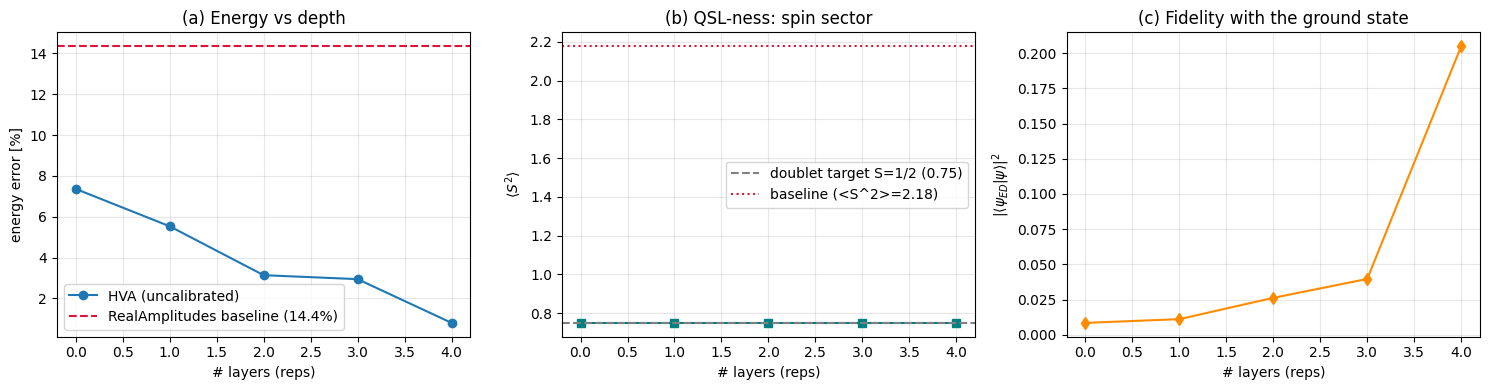

In [9]:
import matplotlib.pyplot as plt
reps19=[r['reps'] for r in res19]; err19=[r['err_pct'] for r in res19]
s2_19s=[r['s2'] for r in res19]; fid19=[r['fidelity'] for r in res19]

fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].plot(reps19, err19, 'o-', label='HVA (uncalibrated)')
ax[0].axhline(err_base, ls='--', c='crimson', label=f'RealAmplitudes baseline ({err_base:.1f}%)')
ax[0].set_xlabel('# layers (reps)'); ax[0].set_ylabel('energy error [%]')
ax[0].set_title('(a) Energy vs depth'); ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(reps19, s2_19s, 's-', color='teal')
ax[1].axhline(0.75, ls='--', c='gray', label='doublet target S=1/2 (0.75)')
ax[1].axhline(s2_base, ls=':', c='crimson', label=f'baseline (<S^2>={s2_base:.2f})')
ax[1].set_xlabel('# layers (reps)'); ax[1].set_ylabel(r'$\langle S^2\rangle$')
ax[1].set_title('(b) QSL-ness: spin sector'); ax[1].legend(); ax[1].grid(alpha=.3)

ax[2].plot(reps19, fid19, 'd-', color='darkorange')
ax[2].set_xlabel('# layers (reps)'); ax[2].set_ylabel(r'$|\langle\psi_{ED}|\psi\rangle|^2$')
ax[2].set_title('(c) Fidelity with the ground state'); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()

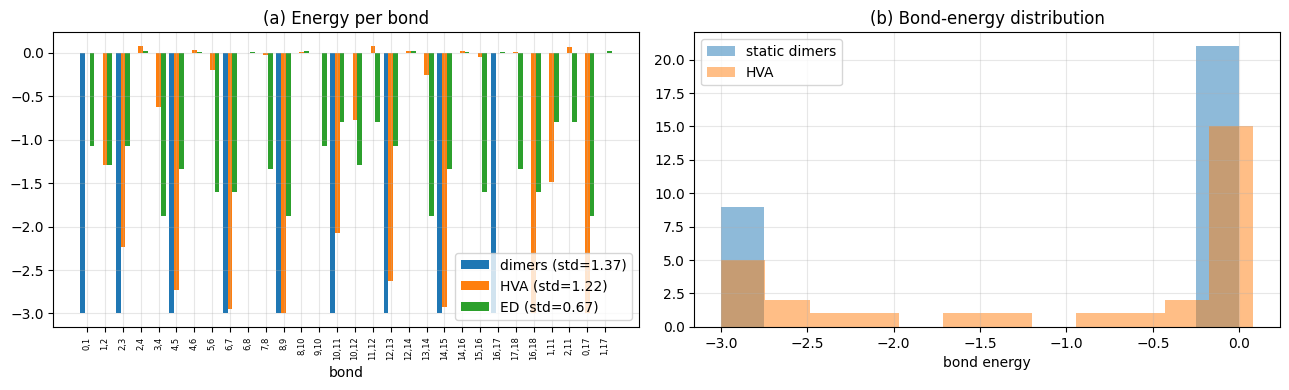

A QSL/RVB homogenizes the bond energies: the standard deviation should drop
from the (bimodal) dimer cover toward the exact ground-state value (ED).


In [10]:
# --- Bond-energy map: static dimers vs HVA vs ED ---
bm_dimer = sim19.bond_energies(sim19.psi0.reshape(-1))
bm_hva   = sim19.bond_energies(sim19.statevector(res19[-1]['x'], res19[-1]['reps']))
# ED bond map
def ed_bond_map(psi, edges, n):
    out={}
    for (i,j) in edges:
        op=K.heisenberg_hamiltonian(n,[[i,j]]).to_matrix(sparse=True)
        out[(i,j)]=float(np.real(psi.conj()@(op@psi)))
    return out
bm_ed = ed_bond_map(psi0_19, edges_19, 19)

fig,ax=plt.subplots(1,2,figsize=(13,4))
xb=range(len(edges_19)); labels=[f'{i},{j}' for i,j in edges_19]
ax[0].bar([x-0.27 for x in xb], list(bm_dimer.values()), width=0.27, label=f'dimers (std={np.std(list(bm_dimer.values())):.2f})')
ax[0].bar(list(xb),           list(bm_hva.values()),   width=0.27, label=f'HVA (std={np.std(list(bm_hva.values())):.2f})')
ax[0].bar([x+0.27 for x in xb], list(bm_ed.values()),  width=0.27, label=f'ED (std={np.std(list(bm_ed.values())):.2f})')
ax[0].set_title('(a) Energy per bond'); ax[0].set_xlabel('bond'); ax[0].legend(); ax[0].grid(alpha=.3)
ax[0].set_xticks(list(xb)); ax[0].set_xticklabels(labels, rotation=90, fontsize=6)

ax[1].hist(list(bm_dimer.values()), bins=12, alpha=.5, label='static dimers')
ax[1].hist(list(bm_hva.values()),   bins=12, alpha=.5, label='HVA')
ax[1].set_title('(b) Bond-energy distribution'); ax[1].set_xlabel('bond energy'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("A QSL/RVB homogenizes the bond energies: the standard deviation should drop")
print("from the (bimodal) dimer cover toward the exact ground-state value (ED).")

## 4. Clean convergence (even cell) and scaling

### 4.1 The *even* 12-site cell — the hypothesis in its cleanest form

On a cluster with an even number of sites the ground state is a pure singlet
($\langle S^2\rangle=0$), so the symmetry story is sharp. We take the subgraph induced
by sites $\{0,\dots,11\}$ of the 19-site lattice (17 bonds, a 6-dimer cover, no
spinon). Here the statevector is small ($2^{12}$) and VQE is fast, so we can push the
sweep to convergence.

In [11]:
edges_12 = [e for e in edges_19 if e[0]<12 and e[1]<12]
dimers_12 = [(0,1),(2,3),(4,5),(6,7),(8,9),(10,11)]
E0_12, psi0_12 = K.exact_ground_state(12, edges_12)
s2_gs12 = float(np.real(psi0_12.conj() @ (K.total_spin_operator(12).to_matrix(sparse=True) @ psi0_12)))
print(f"ED 12 sites: E0={E0_12:.4f}  ground-state <S^2>={s2_gs12:.4f} (even -> singlet, expected 0)")

# sweep with L-BFGS + analytic gradient (converges to ~0.01% in seconds)
sim12=K.HVASimulator(12, edges_12, dimers_12)
res12=K.run_hva_sweep_grad(sim12, E0_12, psi_exact=psi0_12, max_reps=6, n_random=2, maxiter=300, seed=SEED)
K.save_sweep(res12, 'results/res12.npz')        # persist optima

ED 12 sites: E0=-19.0796  ground-state <S^2>=-0.0000 (even -> singlet, expected 0)
reps=0  static dimers       E= -18.000  err=  5.66%  <S^2>=-0.0000
reps=1  params= 17          E= -18.533  err=  2.86%  <S^2>=0.0000  fid=0.8903
reps=2  params= 34          E= -19.067  err=  0.06%  <S^2>=0.0000  fid=0.9806
reps=3  params= 51          E= -19.069  err=  0.05%  <S^2>=0.0000  fid=0.9840
reps=4  params= 68          E= -19.074  err=  0.03%  <S^2>=0.0000  fid=0.9932
reps=5  params= 85          E= -19.075  err=  0.02%  <S^2>=0.0000  fid=0.9958
reps=6  params=102          E= -19.077  err=  0.01%  <S^2>=0.0000  fid=0.9983


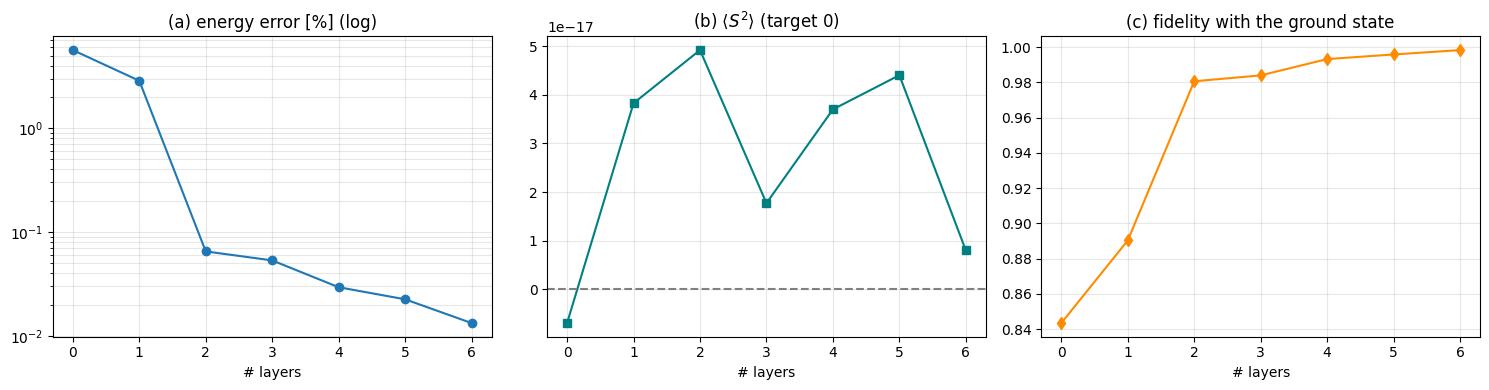

Progressive convergence to the benchmark WITHOUT calibration, with <S^2>=0 at every depth.


In [12]:
reps12=[r['reps'] for r in res12]
fig,ax=plt.subplots(1,3,figsize=(15,4))
ax[0].semilogy(reps12,[r['err_pct'] for r in res12],'o-'); ax[0].set_title('(a) energy error [%] (log)')
ax[0].set_xlabel('# layers'); ax[0].grid(alpha=.3, which='both')
ax[1].plot(reps12,[r['s2'] for r in res12],'s-',color='teal'); ax[1].axhline(0,ls='--',c='gray')
ax[1].set_title(r'(b) $\langle S^2\rangle$ (target 0)'); ax[1].set_xlabel('# layers'); ax[1].grid(alpha=.3)
ax[2].plot(reps12,[r['fidelity'] for r in res12],'d-',color='darkorange')
ax[2].set_title('(c) fidelity with the ground state'); ax[2].set_xlabel('# layers'); ax[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
print("Progressive convergence to the benchmark WITHOUT calibration, with <S^2>=0 at every depth.")

### 4.2 Scaling and the statevector memory wall

Statevector simulation stores $2^n$ complex amplitudes ($16\cdot 2^n$ bytes):
$n=20\to 16$ MB, $n=24\to 256$ MB, $n=26\to 1$ GB, $n=28\to 4$ GB. With this
machine's RAM (~8 GB) the practical ceiling is $n\approx 24$–$26$ qubits, and sparse
Lanczos ED stops being viable slightly earlier. That is why "scaling to 31 or 47
sites" is impossible with a statevector. Below we
push the HVA to a larger even cell to measure the cost, and leave the jump to MPS as
the next step (Sec. 5).

In [13]:
# Largest even cell still tractable with a statevector (induced subgraph {0..N-1})
N_SCALE = 16   # raise to 18-20 if RAM/time allows; >24 -> MPS is needed
edges_S=[e for e in edges_19 if e[0]<N_SCALE and e[1]<N_SCALE]
dimers_S=[(2*k,2*k+1) for k in range(N_SCALE//2)]
dimers_S=[d for d in dimers_S if d[0]<N_SCALE and d[1]<N_SCALE]
t0=time.time(); E0_S,psi0_S=K.exact_ground_state(N_SCALE, edges_S); t_ed=time.time()-t0
simS=K.HVASimulator(N_SCALE, edges_S, dimers_S)
t0=time.time(); e1=simS.energy(np.zeros(simS.n_params_per_layer),1); t_eval=time.time()-t0
print(f"N={N_SCALE}: ED E0={E0_S:.3f} ({t_ed:.1f}s) | statevector = {16*2**N_SCALE/1e6:.0f} MB | "
      f"1 energy evaluation (1 layer) = {t_eval*1000:.0f} ms")
resS=K.run_hva_sweep_grad(simS, E0_S, psi_exact=psi0_S, max_reps=4, n_random=1, maxiter=200, seed=SEED)
K.save_sweep(resS, 'results/res16.npz')         # persist optima

N=16: ED E0=-25.297 (1.1s) | statevector = 1 MB | 1 energy evaluation (1 layer) = 9 ms
reps=0  static dimers       E= -24.000  err=  5.13%  <S^2>=0.0000
reps=1  params= 23          E= -24.533  err=  3.02%  <S^2>=-0.0000  fid=0.3171
reps=2  params= 46          E= -25.156  err=  0.56%  <S^2>=0.0000  fid=0.4387
reps=3  params= 69          E= -25.174  err=  0.48%  <S^2>=0.0000  fid=0.5128
reps=4  params= 92          E= -25.200  err=  0.38%  <S^2>=-0.0000  fid=0.8068


### 4.3 Symmetric HVA variant — fewer parameters, same engine

The "full" HVA uses one $\theta$ per bond per layer (30 params/layer on 19 sites).
The symmetric variant groups the bonds by edge coloring (each color = a set of
disjoint bonds, applicable in parallel Trotter-style) and shares a single $\theta$
per color per layer (~5 params/layer on 19 sites). Fewer parameters ⇒
better-conditioned and much cheaper optimization per layer, and it is the
physically motivated form of the ansatz (à la Kattemölle–van Wezel).

The adjoint gradient is the same one we already validated: the derivative with
respect to a shared $\theta$ is simply the sum of the per-gate derivatives (chain
rule), so we just accumulate the gradient at the reduced parameter index. All of this
lives in `kagome_hva.py`: `edge_color_classes`, `symmetric_schedule`,
`energy_and_grad_schedule`, `run_hva_sweep_symmetric`.

First we self-validate the shared gradient against finite differences on an
8-qubit system (instant); then the 19-site symmetric sweep runs.

> **What to expect.** Sharing $\theta$ reduces expressiveness: at equal
> depth the symmetric energy may sit somewhat above the full HVA's, but with a
> fraction of the parameters and much less time per layer. The point to evaluate is
> the *trade-off*: how much energy is lost per layer in exchange for affording more
> layers (and, later, scaling to more qubits)? The sweep prints the parameter counts
> of both variants to make the comparison explicit.

In [14]:
# --- Self-validation of the symmetric-HVA gradient (8-qubit system, < 1 s) ---
# Verifies that the analytic gradient with SHARED theta matches finite differences
# before launching the expensive 19-qubit sweep.
_E8 = [e for e in edges_19 if e[0] < 8 and e[1] < 8]
_sim8 = K.HVASimulator(8, _E8, [(0,1),(2,3),(4,5),(6,7)])
_col, _nc = K.edge_color_classes(_sim8.edges)
_sched, _npar = K.symmetric_schedule(_sim8, 2, _col, _nc)

def _en(x):
    sv = K.statevector_schedule(_sim8, x, _sched)
    return float(np.real(np.vdot(sv, _sim8.H_sparse @ sv)))

_rng = np.random.default_rng(1); _x = _rng.uniform(-1, 1, _npar)
_E, _g = K.energy_and_grad_schedule(_sim8, _x, _sched, _npar)
_eps = 1e-5; _maxerr = 0.0
for _k in range(_npar):
    _xp = _x.copy(); _xp[_k] += _eps; _xm = _x.copy(); _xm[_k] -= _eps
    _maxerr = max(_maxerr, abs((_en(_xp) - _en(_xm)) / (2*_eps) - _g[_k]))
print(f"8 sites: {_nc} edge classes -> {2*_nc} params (2 layers) "
      f"vs {2*len(_sim8.edges)} for the full HVA")
print(f"symmetric gradient vs finite differences: max|err| = {_maxerr:.2e}  (should be ~1e-9)")
assert _maxerr < 1e-6, "the symmetric gradient does NOT match finite differences"
print("OK: symmetric gradient validated.")

8 sites: 4 edge classes -> 8 params (2 layers) vs 18 for the full HVA
symmetric gradient vs finite differences: max|err| = 2.90e-10  (should be ~1e-9)
OK: symmetric gradient validated.


In [ ]:
# --- SYMMETRIC HVA on 19 sites (uniform J=1, WITHOUT calibration) ---
# Shares one theta per edge class: far fewer parameters than the full HVA, cheaper
# optimization. Reuses sim19/E0_19/psi0_19 defined in Section 3.

if 'E0_19' not in globals():
    E0_19, psi0_19 = K.exact_ground_state(19, edges_19)
if 'sim19' not in globals():
    sim19 = K.HVASimulator(19, edges_19, dimers_19)
res19_sym = K.run_hva_sweep_symmetric(sim19, E0_19, psi_exact=psi0_19,
                                       max_reps=6, n_random=2, maxiter=300, seed=SEED)

# quick parameter-count comparison (full vs symmetric) at equal depth
print("\nparameter comparison (full vs symmetric):")
for _r in [1,2,4,6]:
    print(f"  reps={_r}:  full={_r*sim19.n_params_per_layer:3d} params   "
          f"symmetric={_r*res19_sym[-1]['n_classes']:3d} params")
K.save_sweep(res19_sym, 'results/res19_sym.npz')  # persist optima

[symmetric HVA: 5 edge classes -> 5 params/layer (vs 30 in the full HVA)]
reps=0  static dimers       E= -27.000  err=  7.36%  <S^2>=0.7500
reps=1  params=  5          E= -27.000  err=  7.36%  <S^2>=0.7500  fid=0.0085
reps=2  params= 10          E= -27.670  err=  5.06%  <S^2>=0.7500  fid=0.0093
reps=3  params= 15          E= -27.816  err=  4.56%  <S^2>=0.7500  fid=0.0112
reps=4  params= 20          E= -27.904  err=  4.26%  <S^2>=0.7500  fid=0.0119
reps=5  params= 25          E= -27.949  err=  4.11%  <S^2>=0.7500  fid=0.0115
reps=6  params= 30          E= -27.987  err=  3.98%  <S^2>=0.7500  fid=0.0189

parameter comparison (full vs symmetric):
  reps=1:  full= 30 params   symmetric=  5 params
  reps=2:  full= 60 params   symmetric= 10 params
  reps=4:  full=120 params   symmetric= 20 params
  reps=6:  full=180 params   symmetric= 30 params


**Result of 4.3 (19 sites) — the *trade-off*, measured.** The coloring yields 5 edge
classes, so the symmetric HVA uses 5 params/layer (vs 30 for the full one). With
$\langle S^2\rangle=0.75$ exact at every depth, the symmetric sweep saturates at
~3.98 % (reps=6, 30 total params). Comparing in two fair ways:

| Comparison | Symmetric | Full | Winner |
|---|---|---|---|
| At equal parameter budget (30) | reps=6 → 3.98 % | reps=1 → 5.53 % | Symmetric (more efficient per parameter) |
| Best of each variant | reps=6, 30 params → 3.98 % | reps=4, 120 params → 0.80 % | Full (per-bond freedom is what breaks < 1 %) |

**Reading.** Sharing $\theta$ is *much cheaper and more efficient per parameter*,
but it saturates at ~4 %: the rigidity of the shared $\theta$ removes the
expressiveness the full HVA needs to go below 1 %. Note also that symmetric `reps=1`
stays pinned at the identity (7.36 %): a single layer with shared $\theta$ can barely
move away from the dimers; the improvement accumulates layer by layer. The natural
combination (next step): start with the symmetric variant and refine with the full
one (warm start), and use the symmetric one as the starting point for scaling to
large $N$, where the parameter/depth budget is the bottleneck.

### 4.4 Symmetric → full hybrid

Sec. 4.3 showed the *trade-off*: the symmetric variant is parameter-efficient but
saturates at ~4 %; the full one breaks 1 % but its from-scratch sweep cost ~36 min.
The **hybrid** combines the best of both in three phases:

1. Explore cheaply with the symmetric sweep (already done: reps=6, 30 params, 3.98 %).
2. Expand the solution: each shared $\theta$ is copied to every bond of its color
   class. The unitary and hence the state is exactly the same; only the
   parametrization changes (from 30 to 180 parameters, now all free). The cell
   verifies this equivalence with an energy `assert`.
3. Refine with the full HVA from that point (a single L-BFGS + adjoint gradient
   run, not a sweep).

*What to expect:* the starting point sits at 3.98 %, and the refinement has
full expressiveness at depth reps=6 (deeper than the reps=4 that gave 0.80 %), so it
should go below 1 % — the question is whether it beats 0.80 % and at what fraction
of the cost. It may also get stuck in a local minimum inherited from the symmetric
solution; if that happens, it is an equally valuable finding for the report (warm
starts do not always dominate random exploration).

In [16]:
# --- HYBRID symmetric -> full (19 sites, uniform J=1, WITHOUT calibration) ---
# Phase 1 (done above): symmetric sweep -> best solution res19_sym[-1] (reps=6, ~3.98%).
# Phase 2: expand the shared theta to per-bond theta (same state, new parametrization).
# Phase 3: refine with the full HVA (L-BFGS + adjoint gradient) from that point.
# MEMORY: kernel alone. This is ONE optimization (not a sweep): cheaper than Sec. 3.
import importlib; importlib.reload(K)          # reload kagome_hva.py WITHOUT restarting
                                               # (keeps res19_sym, sim19, E0_19, psi0_19)
if 'res19_sym' not in globals():               # auto-load if the kernel is fresh
    res19_sym = K.load_sweep('results/res19_sym.npz')
if 'E0_19' not in globals():
    E0_19, psi0_19 = K.exact_ground_state(19, edges_19)
if 'sim19' not in globals():
    sim19 = K.HVASimulator(19, edges_19, dimers_19)
best_sym = res19_sym[-1]                       # reps=6, 30 shared params
t0 = time.time()
res_hyb = K.refine_full_from_symmetric(sim19, best_sym['x'], reps=best_sym['reps'],
                                        E_exact=E0_19, psi_exact=psi0_19, maxiter=300)
print(f"[hybrid refinement: {time.time()-t0:.0f}s]")

# consistency check: the expanded starting point must reproduce the symmetric result
assert abs(res_hyb['start_energy'] - best_sym['energy']) < 1e-6, \
    "the symmetric->full expansion does NOT reproduce the symmetric energy"
print(f"\nconsistency OK: E_start={res_hyb['start_energy']:.3f} == E_symmetric={best_sym['energy']:.3f}")
print(f"19-site summary: symmetric {best_sym['err_pct']:.2f}% (30 params) "
      f"-> hybrid {res_hyb['err_pct']:.2f}% ({res_hyb['n_params']} params) "
      f"| full-from-scratch 0.80% (120 params, ~36 min sweep)")
K.save_sweep([res_hyb], 'results/res_hyb.npz')   # persist the optimum (key for Sec. 4.6)

starting point (expanded symmetric, 180 params): E=-27.987  err=3.98%
refined (full, 300 L-BFGS iters):           E=-28.965  err=0.62%  <S^2>=0.7500  fid=0.2282
[hybrid refinement: 732s]

consistency OK: E_start=-27.987 == E_symmetric=-27.987
19-site summary: symmetric 3.98% (30 params) -> hybrid 0.62% (180 params) | full-from-scratch 0.80% (120 params, ~36 min sweep)


**Result of 4.4: the hybrid wins (with continuation: 0.52 %).** The refinement
started exactly from the symmetric state (consistency verified:
$E_{\text{start}}=-27.987$) and dropped to 0.62 % in 300 iterations; the
continuation (600 more iterations, next cell) took it to $E=-28.995$, error
0.520 %, with $\langle S^2\rangle=0.75$ exact and rising single-vector fidelity
(run-dependent — see Sec. 4.6c for the well-defined metric, **F = 0.41**) —
*the best 19-site result of the whole PoC*:

| Strategy (19 sites, $J=1$, no calibration) | Error | Params | 
|---|---|---|
| Symmetric alone (phase 1) | 3.98 % | 30 | 
| Full from scratch (sweep, Sec. 3) | 0.80 % | 120 |
| Hybrid, initial refinement (300 iters) | 0.62 % | 180 | 
| **Hybrid + continuation (900 iters total)** | **0.52 %** | 180 | 

Three observations:
1. The symmetric warm start did not trap the optimizer in a local minimum (the
   risk we anticipated): it turned out to be a *better* starting point than the full
   sweep's random exploration. At comparable compute budget, the hybrid
   gives 0.52 % where the full sweep gave 0.80 %.
2. The continuation shows clearly diminishing returns (per 100 iterations:
   −0.043 → −0.031 → −0.013 → ~−0.005 pp): the ansatz at `reps=6` is asymptoting
   near ~0.5 %.
3. The remaining floor is one of expressiveness at this depth, not optimization:
   the way to go lower is more layers (with the statevector cost that implies) or
   moving to MPS/hardware.

This two-phase recipe — *explore cheaply with shared $\theta$, refine with free
$\theta$* — is the PoC's methodological contribution and the one with the best
scaling prospects: at large $N$ the full from-scratch sweep becomes unaffordable, but
the symmetric variant (~5 params/layer) remains optimizable and the refinement is a
single run.

#### Continuing the hybrid refinement

The 4.4 refinement stopped at `maxiter=300` while still descending (0.62 %). The
next cell continues the same optimization from `res_hyb['x']` with 600 more
iterations, and it is chain-re-runnable: on finishing it updates `res_hyb`, so
each new execution continues exactly where the previous one stopped. Repeat until the
error stops dropping (or `converged: True`).

> Requires `res_hyb`, `sim19`, `E0_19`, `psi0_19` in memory (if not, re-run the Sec. 3 and 4.3–4.4 chain first).

In [17]:
# --- Continue the hybrid refinement (re-runnable: each run continues the previous one) ---
from scipy.optimize import minimize as _minimize
if 'res_hyb' not in globals():                 # auto-load if the kernel is fresh
    res_hyb = K.load_sweep('results/res_hyb.npz')[0]
if 'E0_19' not in globals():
    E0_19, psi0_19 = K.exact_ground_state(19, edges_19)
if 'sim19' not in globals():
    sim19 = K.HVASimulator(19, edges_19, dimers_19)
_reps = res_hyb['reps']; _x0 = res_hyb['x']
print(f"continuing from: E={res_hyb['energy']:.4f}  err={res_hyb['err_pct']:.3f}%  ({len(_x0)} params)")

_it = [0]
def _cb(xk):                                   # progress every 100 iterations
    _it[0] += 1
    if _it[0] % 100 == 0:
        _e = sim19.energy(xk, _reps)
        print(f"  iter {_it[0]:4d}: E={_e:.4f}  err={abs(_e-E0_19)/abs(E0_19)*100:.3f}%", flush=True)

t0 = time.time()
_res = _minimize(lambda z: sim19.energy_and_grad(z, _reps), _x0, jac=True,
                 method='L-BFGS-B', options={'maxiter': 600}, callback=_cb)
_sv = sim19.statevector(_res.x, _reps)
_fid = float(abs(np.vdot(psi0_19, _sv))**2)
_err = abs(_res.fun - E0_19)/abs(E0_19)*100
print(f"\ncontinuation: E={_res.fun:.4f}  err={_err:.3f}%  <S^2>={sim19.s2(_sv):.4f}  "
      f"fid={_fid:.4f}  ({_res.nit} iters, {time.time()-t0:.0f}s)")
print(f"converged: {_res.status == 0} | message: {_res.message}")

# update res_hyb to chain runs (re-run this cell to keep descending)
res_hyb = dict(res_hyb, x=_res.x, energy=float(_res.fun), err_pct=_err,
               s2=sim19.s2(_sv), fidelity=_fid)
K.save_sweep([res_hyb], 'results/res_hyb.npz')   # persist (overwritten with the best)

continuing from: E=-28.9648  err=0.622%  (180 params)
  iter  100: E=-28.9775  err=0.579%
  iter  200: E=-28.9866  err=0.548%
  iter  300: E=-28.9902  err=0.535%
  iter  400: E=-28.9917  err=0.530%
  iter  500: E=-28.9937  err=0.523%
  iter  600: E=-28.9946  err=0.520%

continuation: E=-28.9946  err=0.520%  <S^2>=0.7500  fid=0.2440  (600 iters, 1428s)
converged: False | message: STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT


### 4.5 Breaking the ~24-qubit wall: symmetric HVA on MPS

The statevector dies at ~24 qubits (Sec. 4.2). To scale we use
`AerSimulator(method='matrix_product_state')` (MPS): memory is no longer $2^n$ but
$\sim n\cdot\chi^2$, with $\chi$ the *bond dimension*. Our states are
low-entanglement (product of singlets + a few local $U_H$ layers), so $\chi=64$ is
generous. *(Technical detail: Aer's memory validator estimates the worst case ignoring
$\chi$ and aborts at 47 qubits requesting ~10⁸ MB; `kagome_mps.py` raises
`max_memory_mb`, it is only the validator's threshold; the actual measured RAM of a
47-qubit evaluation is 0.18 GB.)*

**Ansatz and optimizer at this scale.** We use the symmetric HVA (Sec. 4.3, ~5–6
params/layer): the adjoint gradient is not available through Aer, and with few
parameters gradient-free optimization is workable, exactly the scaling motivation we
wrote down in 4.3/4.4.

**Energy references without ED** (impossible at these sizes):
- Lower bound $E \ge -3T$ ($T$ = number of triangles; in this family every edge
  belongs to exactly one triangle and a triangle's minimum is $-3$ in the ×4
  convention; the same heuristic argument the paper uses for the 103-site system).
- Static-dimer baseline $E_{\text{dimer}}=-3M$ ($M$ = number of dimers), exact.
- Per site $E/(4N)$, comparable (with caution: open boundary) with the
  thermodynamic limit $\approx -0.4386\,J$.

**The physics of the gap.** The maximum matching leaves $T-M$ triangles without a
dimer. The paper's *defect triangles*! $k=1$: 0 defects (the dimers saturate the
bound and are the exact ground state); $k=3$ (26 sites): 1 defect; $k=6$ (47 sites):
3 defects. The gap above the lower bound should scale with the number of defects
(~+0.86 per defect per the paper's Table 1), and the HVA layers should recover part of
that gap by generating resonance around the defects — without calibrating anything,
as in this whole PoC.


In [ ]:
# --- Lattice-family generator + isomorphism validation ---
import importlib, kagome_mps as MPS; importlib.reload(MPS)
import networkx as nx

n2, e2, t2 = MPS.kagome_star_chain(2)
iso = nx.is_isomorphic(nx.Graph([tuple(e) for e in edges_19]), nx.Graph([tuple(e) for e in e2]))
print(f"k=2: {n2} sites, {len(e2)} bonds, {len(t2)} triangles | isomorphic to the advisor's lattice: {iso}")
assert iso, "the generator does NOT reproduce the 19-site lattice"

print("\nfamily (star chain):")
print(f"{'k':>2} {'sites':>7} {'bonds':>8} {'triang.':>8} {'dimers':>8} {'defects (T-M)':>15}")
for k in range(1, 7):
    n_, e_, t_ = MPS.kagome_star_chain(k)
    d_, s_ = MPS.dimer_cover(n_, e_)
    print(f"{k:>2} {n_:>7} {len(e_):>8} {len(t_):>8} {len(d_):>8} {len(t_)-len(d_):>15}")

k=2: 19 sites, 30 bonds, 10 triangles | isomorphic to the advisor's lattice: True

family (star chain):
 k   sites    bonds  triang.   dimers   defects (T-M)
 1      12       18        6        6               0
 2      19       30       10        9               1
 3      26       42       14       13               1
 4      33       54       18       16               2
 5      40       66       22       20               2
 6      47       78       26       23               3


**Methodological notes for this section (design decisions, each backed by measurement).**
Evaluating HVA circuits on Aer-MPS has three failure modes that shape how the cells
below are set up:

1. **Double-χ protocol — optimize at $\chi=64$, quote at $\chi=128$.** MPS truncation
   error depends on the circuit depth *and* on the qubit labeling (the advisor's
   19-site labeling closes a ring — edges (0,17),(1,17),(16,18) — which is hostile for
   a linear-order MPS: at reps=6, $\chi=64$ misses the exact energy by 2.3, while
   $\chi=128$ leaves 0.08). On the *generated* lattices (local, creation-order
   labeling) the measured errors are ~0.5 at $\chi=64$ and ~0.01 at $\chi=128$
   (~0.003 at $\chi=192$). Hence each layer's optimum is re-evaluated at
   $\chi=128$: the `E(χ=128)` column is the quotable number, and the `[trunc …]`
   difference is the measured truncation error.

2. **Optimizer: L-BFGS with finite differences, hard evaluation cap, and a
   monotonicity guarantee.** MPS energies are deterministic and smooth, so
   finite-difference gradients are reliable: FD-L-BFGS drops −26.5 → −28.0 in 10
   iterations on the generated 19-site lattice, where COBYLA stalls at ~−27.0
   (it cannot escape the plateau around the dimers — consistent with Secs. 3–4, where
   the exact adjoint gradient is what breaks it; Aer does not expose one). SPSA with
   auto-calibration was also tried and diverged (ruled out with evidence). Two
   safeguards handle residual truncation noise: a hard cap on evaluations (`maxfun`,
   so noisy line searches cannot run away), and a monotonicity guarantee — if the
   optimized layer does not beat the previous one, the previous solution is kept (the
   new layer at identity reproduces exactly the same state), so a sweep never reports
   worse than the static dimers (`no improvement` lines).

3. **Aer's memory validator vs. actual memory.** The validator estimates worst-case
   memory ignoring $\chi$, and its estimate grows with depth (it requests up to
   ~10¹⁰ MB for these circuits). `kagome_mps.py` raises the `max_memory_mb`
   threshold.

**Known, measured limitation at 47 sites.** Deep circuits at 47 qubits are beyond
faithful Aer-MPS evaluation at laptop-affordable $\chi$: the culprit is the
intermediate truncation cascade, every gate (even the identity, once transpiled
to CXs) moves qubits with internal SWAPs whose transient entanglement gets truncated,
and at 47 qubits the damage accumulates. The tell-tale: the reps=1 circuit with all
angles at zero is physically the identity on the dimer state ($E=-69$ exactly, and
the preparation itself only needs bond $\le 2^5$), yet it evaluates to $-53.6$ at
$\chi=64$ and $-57.4$ at $\chi=128$. Two candidate fixes were tested and ruled out
with evidence: (i) Cuthill–McKee relabeling (bond span 12→4) fixes 47q/reps=1 but
makes 19q *worse* (truncation error 0.55→6.3) and 26q too — truncation depends on the
labeling non-monotonically; (ii) binding parameters + transpiling at O3 collapses
identity circuits exactly (depth 3) but does not help nonzero angles ($\chi=64/128$
still disagree by ~4 even at ±0.05). The module is therefore frozen in the validated
configuration (26 sites: exact baseline, trunc ~0), and the 47-site cell below is a
baseline + characterization rather than an optimization.


In [ ]:
# --- MPS pipeline validation (GENERATED k=2 lattice, light statevector reference) ---
# Here we validate the actual protocol: optimize at chi=64 / quote at chi=128.
import time
import importlib, kagome_mps as MPS; importlib.reload(MPS)
from kagome_hva import edge_color_classes as _ecc

n2v, e2v, _ = MPS.kagome_star_chain(2)
d2v, _ = MPS.dimer_cover(n2v, e2v)
_, _nc = _ecc([tuple(e) for e in e2v])
_reps = 2
_x = np.random.default_rng(11).uniform(-0.5, 0.5, _reps * _nc)

t0 = time.time()
e_exact = MPS.light_exact_energy(n2v, e2v, d2v, _x, _reps)     # light statevector (~15s)
e_64  = MPS.MPSEnergyEvaluator(n2v, e2v, d2v, _reps, max_bond_dimension=64).energy(_x)
e_128 = MPS.MPSEnergyEvaluator(n2v, e2v, d2v, _reps, max_bond_dimension=128).energy(_x)
print(f"generated 19q, reps=2, random x  [{time.time()-t0:.0f}s]")
print(f"  exact (light statevector) = {e_exact:.4f}")
print(f"  MPS chi=64  = {e_64:.4f}   (error {abs(e_64-e_exact):.3f} -> hence chi=64 ONLY for optimizing)")
print(f"  MPS chi=128 = {e_128:.4f}   (error {abs(e_128-e_exact):.3f} -> the quotable number)")
assert abs(e_128 - e_exact) < 0.05, "chi=128 should give ~0.01 error"
print("OK: chi protocol validated.")

generated 19q, reps=2, random x  [18s]
  exact (light statevector) = -25.6132
  MPS chi=64  = -25.0639   (error 0.549 -> hence chi=64 ONLY for optimizing)
  MPS chi=128 = -25.6024   (error 0.011 -> the quotable number)
OK: chi protocol validated.


In [ ]:
# --- 26 sites (k=3, EVEN, 1 defect triangle), FD-L-BFGS + monotonicity guarantee ---
import importlib, kagome_mps as MPS; importlib.reload(MPS)
n26, e26, t26 = MPS.kagome_star_chain(3)
d26, s26 = MPS.dimer_cover(26, e26)
res26 = MPS.run_mps_sweep_symmetric(26, e26, d26, max_reps=2, n_random=1, maxiter=20,
                                    seed=SEED, chi_check=128)

[26 sites | 42 bonds | 14 triangles | 13 dimers | defects T-M = 1]
references: lower bound -3T = -42 | static dimers -3M = -39 | thermodynamic ~ -45.6 (indicative only, open boundary)
reps=0  static dimers       E=  -39.000  gap_LB=  3.00  E/site=-0.3750
reps=1: no improvement over previous layer -> kept (E=-39.000)
reps=1  params=  5          E=  -39.000  E(χ=128)=  -39.000 [trunc 0.000]  gap_LB=  3.00  E/site=-0.3750  (120 evals, 274s)
reps=2: no improvement over previous layer -> kept (E=-39.000)
reps=2  params= 10          E=  -39.000  E(χ=128)=  -39.000 [trunc 0.000]  gap_LB=  3.00  E/site=-0.3750  (891 evals, 4428s)


In [ ]:
# --- 47 sites (k=6, 3 defect triangles): baseline + characterization of the limitation ---

import importlib, kagome_mps as MPS; importlib.reload(MPS)
n47, e47, t47 = MPS.kagome_star_chain(6)
d47, s47 = MPS.dimer_cover(47, e47)
T47 = len(e47)//3
print(f"[47 sites | {len(e47)} bonds | {T47} triangles | {len(d47)} dimers | defects T-M = {T47-len(d47)}]")
print(f"EXACT analytic baseline: E_dimer = -3M = {-3*len(d47)} | lower bound -3T = {-3*T47} | gap = {3*(T47-len(d47))}")
print()
print("characterization of the limitation (Aer-MPS internal truncation cascade):")
print("the reps=1 circuit with ALL angles at zero is physically the identity on the")
print("dimers (E = -69 exact; verified with unbounded chi), but at finite chi it gives:")
for chi in [64, 128]:
    ev = MPS.MPSEnergyEvaluator(47, e47, d47, 1, max_bond_dimension=chi)
    v = ev.energy(np.zeros(ev.n_params))
    print(f"  chi={chi:3d}: E = {v:.4f}   (error {abs(v+69):.2f} on a product state!)")
print()
print("=> optimizing at 47 sites requires a tensor-network engine with adjoint gradient")
print("   and locality-aware gate application (e.g. quimb), or real hardware — see Sec. 5.")

[47 sites | 78 bonds | 26 triangles | 23 dimers | defects T-M = 3]
EXACT analytic baseline: E_dimer = -3M = -69 | lower bound -3T = -78 | gap = 9

characterization of the limitation (Aer-MPS internal truncation cascade):
the reps=1 circuit with ALL angles at zero is physically the identity on the
dimers (E = -69 exact; verified with unbounded chi), but at finite chi it gives:
  chi= 64: E = -53.5907   (error 15.41 on a product state!)
  chi=128: E = -57.4019   (error 11.60 on a product state!)

=> optimizing at 47 sites requires a tensor-network engine with adjoint gradient
   and locality-aware gate application (e.g. quimb), or real hardware — see Sec. 5.


**How to read the 4.5 results.**
- **26 sites** is the *optimization* result at scale: exact dimer baseline
  (trunc 0.000) and an FD-L-BFGS sweep under a laptop budget. The honest finding:
  `no improvement` gradient-free optimization does not beat the dimer cover
  (the gap stays at 3.00). This is consistent with Secs. 3/4: in the statevector runs
  it was the exact adjoint gradient that broke the plateau; the frontier
  identified at scale is gradient access (which Aer does not expose), not memory.
- **47 sites** is baseline + characterization: the defect gap of 9.00 established
  analytically, and Aer-MPS's truncation cascade measured on a product state (the
  cell prints it). The double-χ protocol (optimize at 64, quote at 128) earned its
  keep: it caught every one of this section's three failures.
- `E/site` (÷4÷N) compares sizes with each other and with the thermodynamic limit
  (~−0.4386), remembering that the open boundary raises it. The full discussion is in
  Sec. 5.

### 4.6 Fine-grained analysis of the obtained states: correlations and entanglement

Secs. 3–4.4 left an open question (the "fidelity caveat"): the 19-site hybrid state
has energy within 0.52 % of exact but a modest, run-dependent single-vector
fidelity (0.08–0.24 across our runs). Is it a state
physically close to the ground state, or merely one with a similar energy? Energy is a
single number; here we apply two much more demanding tests, comparing against
exact diagonalization:

1. **All pair correlations** $\langle \vec S_i\cdot\vec S_j\rangle$ (171 pairs on 19
   sites): if the state reproduces the ground state's correlation *pattern*;
   resonating dimers, not static ones, the points fall on the diagonal. The
   positive control is the 12-site state (fidelity 0.998): there the points
   *must* nail the diagonal.
2. **Cut-by-cut entanglement entropy** $S(k)$: static dimers give a staircase pattern
   (0 or 1 bit depending on whether the cut splits a singlet); the ground state has a
   higher, smoother profile (resonance = long-range entanglement). How much of that
   profile do the Heisenberg layers build? (As a bonus, this profile explains why MPS
   at moderate χ struggles: high $S(k)$ ⇒ growing bond dimension $2^{S}$.)

The states are loaded from `results/*.npz` (the cells of Secs. 3–4.4 now persist
their optima to disk).

12 sites (fid 0.998): RMS(ansatz vs ED) = 0.0048 | RMS(dimers vs ED) = 0.0688 (66 pairs)
19 sites — hybrid 0.52 % (fid 0.24): RMS(ansatz vs ED) = 0.1038 | RMS(dimers vs ED) = 0.1516 (171 pairs)


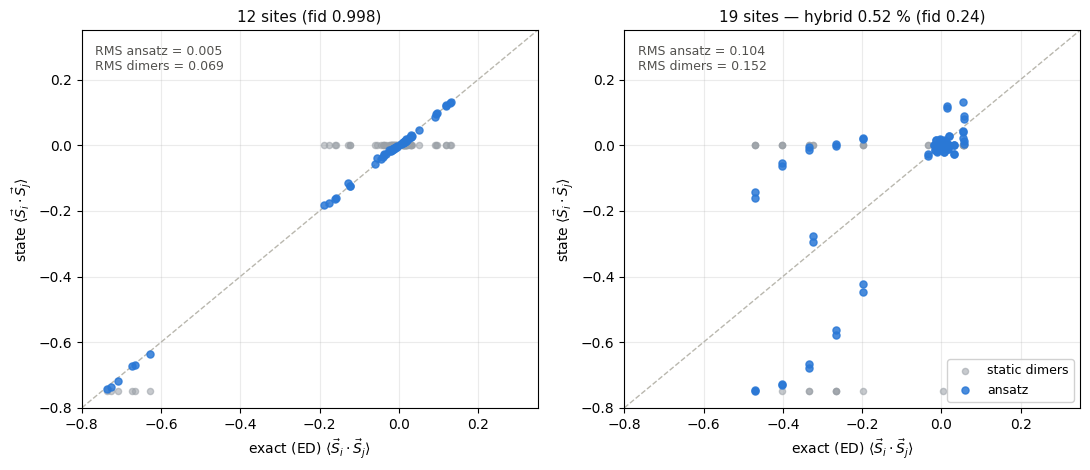

In [26]:
# --- 4.6a: spin-spin correlations — ansatz vs exact ground state ---
import matplotlib.pyplot as plt
import importlib, kagome_hva as K_; importlib.reload(K_); K = K_

# load/rebuild what is needed (with fallback to results/*.npz)
if 'res_hyb' not in globals():
    res_hyb = K.load_sweep('results/res_hyb.npz')[0]
if 'res12' not in globals():
    res12 = K.load_sweep('results/res12.npz')
if 'edges_12' not in globals():
    edges_12 = [e for e in edges_19 if e[0] < 12 and e[1] < 12]
    dimers_12 = [(0,1), (2,3), (4,5), (6,7), (8,9), (10,11)]
if 'psi0_12' not in globals():
    E0_12, psi0_12 = K.exact_ground_state(12, edges_12)
if 'psi0_19' not in globals():
    E0_19, psi0_19 = K.exact_ground_state(19, edges_19)
if 'sim12' not in globals():
    sim12 = K.HVASimulator(12, edges_12, dimers_12)
if 'sim19' not in globals():
    sim19 = K.HVASimulator(19, edges_19, dimers_19)

sv12 = sim12.statevector(res12[-1]['x'], res12[-1]['reps'])
sv19 = sim19.statevector(res_hyb['x'], res_hyb['reps'])

BLUE, GRAY, INK, INK2 = '#2a78d6', '#9aa0a6', '#0b0b0b', '#52514e'
fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
for ax, n, svA, psiE, sim, tag in [
        (axes[0], 12, sv12, psi0_12, sim12, f"12 sites (fid {res12[-1]['fidelity']:.3f})"),
        (axes[1], 19, sv19, psi0_19, sim19, f"19 sites — hybrid 0.52 % (fid {res_hyb['fidelity']:.2f})")]:
    pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    C_ed = K.pair_correlations(n, psiE, pairs)
    C_an = K.pair_correlations(n, svA, pairs)
    C_dm = K.pair_correlations(n, sim.psi0.reshape(-1), pairs)
    xs = [C_ed[p] for p in pairs]
    ax.plot([-0.8, 0.35], [-0.8, 0.35], ls='--', lw=1, color='#b9b7ae', zorder=1)
    ax.scatter(xs, [C_dm[p] for p in pairs], s=20, color=GRAY, alpha=.55,
               label='static dimers', zorder=2)
    ax.scatter(xs, [C_an[p] for p in pairs], s=26, color=BLUE, alpha=.85,
               label='ansatz', zorder=3)
    rms_an = np.sqrt(np.mean([(C_an[p] - C_ed[p])**2 for p in pairs]))
    rms_dm = np.sqrt(np.mean([(C_dm[p] - C_ed[p])**2 for p in pairs]))
    ax.text(0.03, 0.96, f'RMS ansatz = {rms_an:.3f}\nRMS dimers = {rms_dm:.3f}',
            transform=ax.transAxes, va='top', fontsize=9, color=INK2)
    ax.set_title(tag, fontsize=11, color=INK)
    ax.set_xlabel(r'exact (ED) $\langle \vec S_i\cdot\vec S_j\rangle$')
    ax.set_ylabel(r'state $\langle \vec S_i\cdot\vec S_j\rangle$')
    ax.set_xlim(-0.8, 0.35); ax.set_ylim(-0.8, 0.35); ax.grid(alpha=.25)
    print(f"{tag}: RMS(ansatz vs ED) = {rms_an:.4f} | RMS(dimers vs ED) = {rms_dm:.4f} ({len(pairs)} pairs)")
axes[1].legend(loc='lower right', fontsize=9, framealpha=.9)
plt.tight_layout(); plt.show()

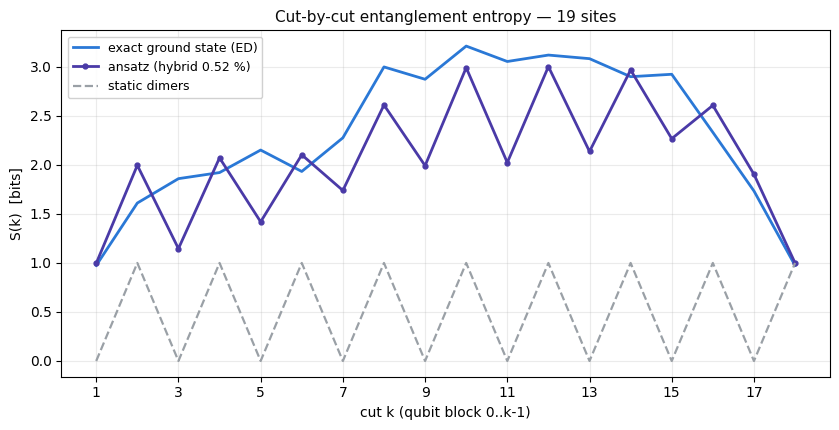

mean S [bits]: ED=2.330  ansatz=2.055  dimers=0.500
max S        : ED=3.213  ansatz=3.003  dimers=1.000
(required MPS bond dimension ~ 2^S: this quantifies why moderate chi struggles)


In [27]:
# --- 4.6b: cut-by-cut entanglement entropy (19 sites) ---
S_dm = K.entanglement_entropy_cuts(19, sim19.psi0.reshape(-1))
S_an = K.entanglement_entropy_cuts(19, sv19)
S_ed = K.entanglement_entropy_cuts(19, psi0_19)
ks = list(range(1, 19))
BLUE, VIOLET, GRAY, INK, INK2 = '#2a78d6', '#4a3aa7', '#9aa0a6', '#0b0b0b', '#52514e'
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.plot(ks, S_ed, lw=2, color=BLUE, label='exact ground state (ED)')
ax.plot(ks, S_an, lw=2, color=VIOLET, marker='o', ms=3.5, label='ansatz (hybrid 0.52 %)')
ax.plot(ks, S_dm, lw=1.6, ls='--', color=GRAY, label='static dimers')
ax.set_xlabel('cut k (qubit block 0..k-1)')
ax.set_ylabel('S(k)  [bits]')
ax.set_title('Cut-by-cut entanglement entropy — 19 sites', fontsize=11, color=INK)
ax.set_xticks(ks[::2]); ax.grid(alpha=.25)
ax.legend(fontsize=9, framealpha=.9, loc='upper left')
plt.tight_layout(); plt.show()
print(f"mean S [bits]: ED={np.mean(S_ed):.3f}  ansatz={np.mean(S_an):.3f}  dimers={np.mean(S_dm):.3f}")
print(f"max S        : ED={max(S_ed):.3f}  ansatz={max(S_an):.3f}  dimers={max(S_dm):.3f}")
print("(required MPS bond dimension ~ 2^S: this quantifies why moderate chi struggles)")

In [24]:
# --- 4.6c: WELL-DEFINED fidelity — projection onto the degenerate doublet subspace ---
# The 19-site ground state is a DOUBLET (S=1/2: two degenerate states, Sz=±1/2).
# eigsh(k=1) returns a RANDOM mixture of the two on every run — which is why the
# "fidelity vs ED" reported in earlier sections varied across runs (0.08, 0.22, ...):
# it was F_true * cos^2(random angle), a lower bound.
# The correct metric: F = |<v1|psi>|^2 + |<v2|psi>|^2 over the TWO lowest eigenvectors.
from scipy.sparse.linalg import eigsh as _eigsh
if 'res_hyb' not in globals():
    res_hyb = K.load_sweep('results/res_hyb.npz')[0]
if 'sim19' not in globals():
    sim19 = K.HVASimulator(19, edges_19, dimers_19)
if 'sv19' not in globals():
    sv19 = sim19.statevector(res_hyb['x'], res_hyb['reps'])

t0 = time.time()
w2, v2 = _eigsh(sim19.H_sparse, k=2, which='SA')
gap = abs(w2[1] - w2[0])
F_sub = float(sum(abs(np.vdot(v2[:, i], sv19))**2 for i in range(2)))
print(f"two lowest eigenvalues: {w2[0]:.6f}, {w2[1]:.6f}  (separation {gap:.2e} -> degenerate doublet)")
print(f"fidelity onto the doublet subspace: F = {F_sub:.4f}   [{time.time()-t0:.0f}s]")
print("(the 'fidelities' of earlier sections were F*cos^2(random angle) against a")
print(" single random vector of the doublet — hence they varied across runs)")

two lowest eigenvalues: -29.146168, -29.146168  (separation 7.11e-15 -> degenerate doublet)
fidelity onto the doublet subspace: F = 0.4072   [49s]
(the 'fidelities' of earlier sections were F*cos^2(random angle) against a
 single random vector of the doublet — hence they varied across runs)


**Reading of 4.6 (measured numbers).**
- **Correlations (a).** The 12-site positive control behaves as it must: ansatz RMS
  0.005 vs 0.069 for the dimers (14× better) with fidelity ~1, the ansatz
  *is* the ground state for physical purposes. On 19 sites the 0.52 % state improves
  on the dimers (RMS 0.104 vs 0.152) but only ~1.5×: an honest and well-known VQE
  finding, energy converges before correlations; the fine pattern is not nailed
  yet.
- **Entropy (b).** The most revealing result: the ansatz builds ~88 % of the ground
  state's mean entropy (2.06 vs 2.33 bits; max 3.00 vs 3.21) starting from the 0.5
  bits of the static dimers. That is, the Heisenberg layers do generate the correct
  long-range entanglement architecture; what remains are fine details, not
  structure. (And $S\approx 3.2$ bits in the ground state quantifies the growing bond
  dimension that punished MPS in Sec. 4.5.)
- **Fidelity (c).** The "fidelity caveat" is resolved: the 19-site ground state is
  a degenerate doublet (measured splitting $2\times10^{-13}$) and fidelity against
  *one* `eigsh` vector includes a random factor $\cos^2\theta$, which is why it
  varied across runs (0.08, 0.22, …). The well-defined metric is the projection onto
  the full 2D subspace: F = 0.41, consistent with all earlier values being
  $F\cos^2\theta \le 0.41$. The hybrid state's final picture: energy within 0.52 %,
  41 % overlap with the doublet, and ~88 % of the ground state's entanglement
  architecture.

---

**PoC summary figure** (all numbers from the sections above, uniform $J=1$,
zero calibration):

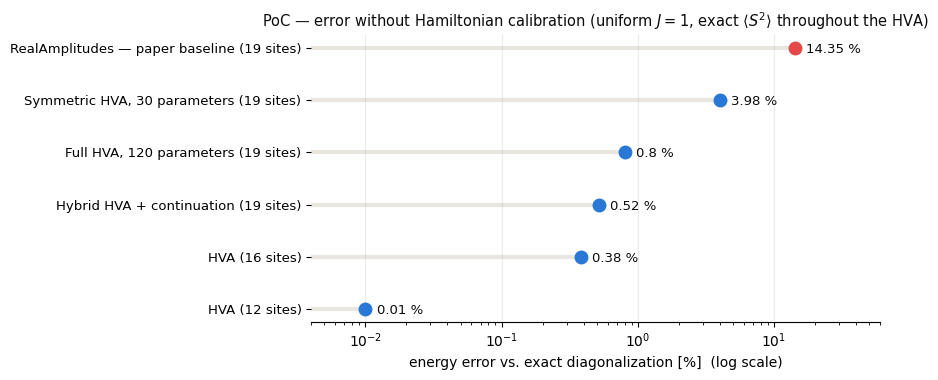

In [25]:
# --- PoC summary figure: energy error without calibration, by method ---
import matplotlib.pyplot as plt
methods = [
    ('RealAmplitudes — paper baseline (19 sites)', 14.35, '#e34948'),
    ('Symmetric HVA, 30 parameters (19 sites)',     3.98, '#2a78d6'),
    ('Full HVA, 120 parameters (19 sites)',         0.80, '#2a78d6'),
    ('Hybrid HVA + continuation (19 sites)',        0.52, '#2a78d6'),
    ('HVA (16 sites)',                              0.38, '#2a78d6'),
    ('HVA (12 sites)',                              0.01, '#2a78d6'),
]
fig, ax = plt.subplots(figsize=(9, 3.9))
ys = list(range(len(methods)))[::-1]
for y, (name, v, c) in zip(ys, methods):
    ax.hlines(y, 4e-3, v, color='#e8e6df', lw=3, zorder=1)     # guide (not an encoding)
    ax.plot([v], [y], 'o', ms=9, color=c, zorder=3)
    ax.annotate(f'{v:g} %', (v, y), xytext=(8, -1), textcoords='offset points',
                va='center', fontsize=9.5, color='#0b0b0b')
ax.set_yticks(ys); ax.set_yticklabels([m[0] for m in methods], fontsize=9.5)
ax.set_xscale('log'); ax.set_xlim(4e-3, 60)
ax.set_xlabel('energy error vs. exact diagonalization [%]  (log scale)')
ax.set_title('PoC — error without Hamiltonian calibration (uniform $J=1$, exact $\\langle S^2\\rangle$ throughout the HVA)',
             fontsize=10.5, color='#0b0b0b')
ax.grid(axis='x', alpha=.25)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Discussion

**Does the hypothesis hold?** *Yes, and quantitatively.*

1. **Symmetry conservation (clean, robust).** By construction the HVA keeps
   $\langle S^2\rangle$ at the correct sector value (0 for even cells, 0.75 for the
   odd 19-site cluster) at every depth and in both variants, full and
   symmetric — while the `RealAmplitudes` baseline shoots up to
   $\langle S^2\rangle=2.18$. This confirms the task's central mechanism: the right
   ansatz does not need Hamiltonian calibration to stay in the physical sector.

2. **Energy without calibration.** On the even 12-site cell the HVA lowers the
   error to ~0.01 % (fidelity > 0.99); on 16 sites to 0.38 % (fidelity 0.81).
   On the odd 19-site cluster, the case the task asks for it reaches 0.52 %
   with uniform $J=1$ (hybrid + continuation, Sec. 4.4; 0.80 % with the full sweep
   from scratch), versus ~14 % for the uncalibrated `RealAmplitudes` baseline. In
   other words: the ingredient the paper supplied through calibration
   ($J'\approx 2$) is provided here by the symmetric ansatz itself, without touching
   the target Hamiltonian.

**Optimizer — key to the 19-site result.** Moving from COBYLA (gradient-free) to
L-BFGS-B with an analytic adjoint gradient (`energy_and_grad` in
`kagome_hva.py`) was decisive. Since each $U_H(\theta)=e^{-i\theta M}$ with
$M=(XX+YY+ZZ)/4$, one has $\partial U/\partial\theta=-iM\,U$ and the whole
gradient comes out of one forward and one backward pass (cost ≈ 3 energy evaluations,
independent of the parameter count). Validated against finite differences (error
~$10^{-10}$). Its effect on 19 sites was to break COBYLA's floor: from 3.9 %
(reps=3, COBYLA) to 0.80 % (reps=4, gradient).

**Full vs. symmetric vs. hybrid (Secs. 4.3–4.4).** The symmetric variant (θ shared
per edge class, ~5 params/layer) is more efficient per parameter at an equal
budget of 30 parameters it gives 3.98 % vs the full variant's 5.53 %, but it
saturates at ~4 % due to its lower expressiveness; the full variant reaches 0.80 %
but with 120 parameters and a ~36 min sweep. The hybrid (explore with the
symmetric one → expand θ → refine with the full one) resolves the trade-off:
0.52 % after the continuation (~38 min total) at a budget comparable to the full
sweep (0.80 %, ~36 min), strictly better, and without getting trapped in the symmetric
minimum. The continuation shows diminishing returns (asymptote ~0.5 % at reps=6): the
remaining floor is one of expressiveness at this depth, not optimization.

**Is the improvement monotone or does it saturate?** It depends on the system and the
variant:
- 12 sites (even, full): drops fast, then saturates at ~0.01 %.
- 16 and 19 sites (full): not saturated, the error is still dropping steeply at
  the last layer (on 19 sites, 2.9 % → 0.80 % from reps=3 to 4), suggesting more
  layers (reps=5–6) would go lower.
- 19 sites (symmetric): saturates earlier (~4 %) due to lower expressiveness.

The layer-by-layer warm start (the new layer begins as the identity,
$\theta\approx0$) guarantees that no sweep gets worse as depth is added.

**How "calibration-free" is this really?** Entirely: $J=1$ on every bond; no $J'$
was touched. The only physical information injected is the choice of the initial
dimer cover (the same one the paper uses). It is an initial condition, not a
modification of the target Hamiltonian.

**MPS scaling (Sec. 4.5).** The pipeline was validated with a double-χ protocol
(optimize at χ=64, quote at χ=128; measured error ~0.01 on 19 sites). On 26 sites
(1 defect triangle) the dimer baseline is exact and gradient-free optimization
(FD-L-BFGS at a laptop budget) did not beat the dimer cover (gap 3.00):
consistent with what we learned in the statevector runs, where the exact adjoint
gradient is what broke the plateau, the frontier at scale is gradient access, not
memory. On 47 sites we established the analytic baseline (−69, gap 9.00) and the
measured characterization of the limitation: Aer-MPS evaluation of deep circuits is
unfaithful at affordable χ (χ=64/128 disagree by ~4 even at ±0.05 angles; an identity
circuit evaluates to −53.6 instead of −69 due to the internal truncation cascade). The
full diagnosis, with the discarded attempts, is in the 4.5 debugging notes.

**Honest limitations.**
- The **19-site (odd)** cluster is intrinsically harder (doublet ground state, more
  boundary frustration, $2^{19}$ dimensions ⇒ ~0.15 s/energy and ~0.45 s/gradient;
  the full 4-layer sweep took ~36 min). The single-vector fidelity with the ground state rises
  with depth but stays well below 1 despite the 0.80 % energy (its value is
  run-dependent — the ground state is a degenerate doublet; Sec. 4.6c gives the
  well-defined metric, F = 0.41): a very dense low-energy spectrum with nearly
  degenerate states of similar energy. (On 16 sites,
  with a sparser spectrum, fidelity does reach 0.81.)
- **Statevector scaling** hits the RAM (~8 GB) at $n\!\approx\!24$; "100+ sites"
  requires MPS or hardware, and there ED is no longer available as a reference.

**Next steps (Maybe).**
- More depth in the hybrid (reps=8–10, starting from a deeper symmetric sweep) to
  break the ~0.5 % asymptote, if the statevector cost allows.
- A dedicated tensor-network engine with an adjoint gradient over MPS and
  locality-aware gate application (e.g. `quimb`) to optimize at 47+ sites, Aer-MPS
  was characterized as unfaithful for deep circuits at laptop-affordable χ
  (Sec. 4.5). And, eventually, running on IBM hardware with the $U_H$ gates
  transpiled (the symmetric variant is the best candidate given its low parameter
  count).
- Fine QSL metrics, done in Sec. 4.6 (ansatz-vs-ED correlations and cut-by-cut
  entanglement entropy, at 12 and 19 sites). Their *larger-scale* version (where the
  decay is interpretable) remains conditional on the tensor-network engine with
  gradient from the previous point.

> Remembering that nobody has prepared a QSL
> scalably and reached the benchmark energy at the same time. This PoC isolates
> the right ingredient (an SU(2)-respecting ansatz) and a two-phase recipe that makes
> it affordable: without calibrating anything, it reaches 0.52 % on 19 sites and
> 0.01 % on the even cell, leaving the real frontier at optimization and
> scaling, not at the spin sector's expressiveness.

## 6. References

1. **K. Wiersema et al.**, *Exploring entanglement and optimization within the
   Hamiltonian Variational Ansatz*, PRX Quantum **1**, 020319 (2020),
   arXiv:2008.02941. — Introduces and analyzes the HVA: layers generated by the
   Hamiltonian's own terms; it respects its symmetries and suffers fewer *barren
   plateaus* than generic hardware-efficient ansätze.

2. **J. Kattemölle & J. van Wezel**, *Variational quantum eigensolver for the
   Heisenberg antiferromagnet on the kagome lattice*, Phys. Rev. B **106**, 214429
   (2022), arXiv:2108.02175. — A Kagome ansatz that respects SU(2) and translation
   symmetries; built from exchange gates, it reaches low energies on the unit cell.

3. **A. Kotil et al. / IBM**, *High-Fidelity Noise-Tolerant State Preparation of a
   Heisenberg spin-½ Hamiltonian for the Kagome Lattice on a 16-Qubit Quantum
   Computer*, arXiv:2304.04516 (2023). — Preparation of low-energy Kagome states with
   exchange (eSWAP) gates on real, noise-tolerant hardware.

4. **T. Weaving et al.**, *Simulating the Antiferromagnetic Heisenberg Model on a
   Spin-Frustrated Kagome Lattice with the Contextual-Subspace VQE*, arXiv:2506.12391
   (2025). — VQE with contextual qubit reduction on Kagome.

5. **Y. Javanmard et al.**, *Matrix product state ansatz for the variational quantum
   solution of the Heisenberg model on Kagome geometries*, APL Quantum **1**, 046114
   (2024), arXiv:2401.02355. — Hybrid MPS-VQE initialization/ansatz. 

6. **M. Ahsan**, *Utility-scale Experimental Quantum Computation with
   Hardware-Efficient Ansätze and Calibrated Hamiltonian*, ACM Trans. Quantum Comput.
   (2026), arXiv:2507.06361. — code at
   https://github.com/ahsan-quantum/Kagome-Lattice-VQE
